# Анализ данных крупного интернет-магазина

## Цели и задачи проекта

В этом проекте нам предстоит проанализировать данные крупного интернет-магазина, который работает преимущественно в Азии. 

Магазин недавно провёл А/B-тест, чтобы проверить новую платёжную воронку: гипотеза заключалась в том, что новая платёжная воронка увеличит конверсию в покупку. 

Наша цель – проанализировать результаты А/B-теста, который назывался `new_payment_funnel_test_summer_2025`.

## Описание данных

Нам понадобится поработать со следующими файлами:
- `new_users_test_2025.csv` — данные всех пользователей, зарегистрировавшихся в интернет-магазине с 1 по 14 июня 2025 года.
- `sessions_test_2025.csv` — данные всех сессий новых пользователей с 1 по 21 июня 2025 года.
- `purchases_test_2025.csv` — данные всех покупок новых пользователей с 1 по 21 июня 2025 года.
- `participants_test_2025.csv` — данные участников тестов.

Структура данных выглядит следующим образом:

Поля таблицы `new_users_test_2025.csv`:

- `user_id` — уникальный идентификатор пользователя;
- `first_date` — дата регистрации;
- `region` — регион, к которому относится пользователь;
- `device` — устройство, с которого происходила регистрация.

Таблица `sessions_test_2025.csv` состоит из полей:
- `user_id` — уникальный идентификатор пользователя;
- `session_start` — дата начала сессии;
- `session_duration` — длительность сессии в минутах.

Таблица `purchases_test_2025.csv` состоит из полей:
- `user_id` — уникальный идентификатор пользователя;
- `event_dt` — дата и время покупки;
- `revenue` — стоимость покупки в долларах.

Таблица `participants_test_2025.csv` состоит из полей:
- `user_id` — уникальный идентификатор пользователя;
- `group` — группа А/B-теста;
- `ab_test` — название А/B-теста.

## Загрузка и знакомство с данными

In [1]:
# Импортируем библиотеку pandas
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Выгружаем данные из датасетов 
new_users = pd.read_csv("new_users_test_2025.csv")
sessions = pd.read_csv("sessions_test_2025.csv")
purchases = pd.read_csv("purchases_test_2025.csv")
participants = pd.read_csv("participants_test_2025.csv")

In [3]:
# Выводим информацию о датафрейме new_users
new_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131486 entries, 0 to 131485
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   user_id     131486 non-null  object
 1   first_date  131486 non-null  object
 2   region      131486 non-null  object
 3   device      131486 non-null  object
dtypes: object(4)
memory usage: 4.0+ MB


In [4]:
# Выводим первые строки датафрейма на экран
new_users.head()

,user_id,first_date,region,device
0,D72A72121175D8BE,2025-06-01,South Asia,iPhone
1,F1C668619DFE6E65,2025-06-01,Southeast Asia,iPhone
2,2E1BF1D4C37EA01F,2025-06-01,Central Asia,Mac
3,50734A22C0C63768,2025-06-01,Central Asia,Android
4,E1BDDCE0DAFA2679,2025-06-01,Southeast Asia,iPhone


**Вывод по датасету `new_users`**

Датасет new_users содержит информацию о новых пользователях интернет-магазина, которые зарегистрировались в период проведения анализа.

В таблице представлено 131 486 строк  и 4 колонки.

Пропущенных значений в таблице нет: во всех столбцах указано 131 486 non-null значений. Это значит, что на данном этапе данные выглядят полными и не требуют обработки пропусков.

Итог: датасет new_users готов для дальнейшего анализа. Нужно только преобразовать столбец first_date из типа object в формат даты datetime, чтобы корректно работать с периодами регистрации пользователей.

In [5]:
# Выводим информацию о датафрейме sessions
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491443 entries, 0 to 491442
Data columns (total 3 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   user_id           491443 non-null  object 
 1   session_start     491443 non-null  object 
 2   session_duration  491443 non-null  float64
dtypes: float64(1), object(2)
memory usage: 11.2+ MB


In [6]:
# Выводим первые строки датафрейма на экран
sessions.head()

,user_id,session_start,session_duration
0,D72A72121175D8BE,2025-06-01 05:51:20,1.0
1,F1C668619DFE6E65,2025-06-01 15:28:14,5.0
2,2E1BF1D4C37EA01F,2025-06-01 16:19:36,3.0
3,50734A22C0C63768,2025-06-01 21:06:51,1.0
4,E1BDDCE0DAFA2679,2025-06-01 10:03:00,2.0


**Вывод по датасету `sessions`**

Датасет sessions содержит информацию о длительности сессий пользователей интернет-магазина.

В таблице представлено 491 443 строки  и 4 колонки.

Пропущенных значений в таблице нет: во всех столбцах указано 491 443 non-null значений. Это значит, что на данном этапе данные выглядят полными и не требуют обработки пропусков.


Итог: датасет sessions готов для дальнейшего анализа. Нужно только преобразовать столбец session_start из типа object в формат даты datetime, чтобы корректно анализировать активность пользователей по дням, неделям и периодам A/B-теста.

In [7]:
# Выводим информацию о датафрейме purchases
purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149152 entries, 0 to 149151
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   user_id   149152 non-null  object 
 1   event_dt  149152 non-null  object 
 2   revenue   149152 non-null  float64
dtypes: float64(1), object(2)
memory usage: 3.4+ MB


In [8]:
# Выводим первые строки датафрейма на экран
purchases.head()

,user_id,event_dt,revenue
0,50734A22C0C63768,2025-06-01 21:06:51,4.99
1,0FC21E6F8FAA8DEC,2025-06-01 06:36:08,4.99
2,9CD9F34546DF254C,2025-06-01 14:40:29,99.99
3,1FD7660FDF94CA1F,2025-06-01 04:53:00,4.99
4,E6AF85675078215D,2025-06-01 11:40:09,4.99


**Вывод по датасету `purchases`**

Датасет purchases содержит информацию о покупках пользователей интернет-магазина.

В таблице 149 152 строки и 3 столбца.

Пропущенных значений в датасете нет: во всех столбцах указано 149 152 non-null значений. Это значит, что данные по покупкам заполнены полностью и на данном этапе не требуют обработки пропусков.

Столбец event_dt сейчас имеет тип object, хотя содержит дату и время покупки. Для дальнейшего анализа его нужно будет преобразовать в формат datetime, чтобы корректно анализировать покупки по дням, периодам и группам теста.

Итог: датасет purchases готов для дальнейшего анализа. Он поможет оценить ключевые бизнес-метрики A/B-теста: конверсию в покупку, количество покупок, средний чек и выручку по контрольной и тестовой группам.

In [9]:
# Выводим информацию о датафрейме participants
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3291 entries, 0 to 3290
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  3291 non-null   object
 1   group    3291 non-null   object
 2   ab_test  3291 non-null   object
dtypes: object(3)
memory usage: 77.3+ KB


In [10]:
# Выводим первые строки датафрейма на экран
participants.head()

,user_id,group,ab_test
0,6A8825D752FCFFB6,A,new_payment_funnel_test_summer_2025
1,0B75608CBBA59791,B,new_payment_funnel_test_summer_2025
2,6B9D2F7685B83C73,A,new_payment_funnel_test_summer_2025
3,6435D4C2E66A7F75,B,new_payment_funnel_test_summer_2025
4,4F815438BBD2BB7E,A,new_payment_funnel_test_summer_2025


**Вывод по датасету `participants`**

Датасет participants содержит информацию об участниках A/B-теста интернет-магазина.

В таблице 3 291 строка и 3 столбца.

Пропущенных значений в датасете нет: во всех столбцах указано 3 291 non-null значений. Это значит, что данные об участниках теста заполнены полностью и не требуют обработки пропусков.

Также во всех первых строках указан один и тот же тест — new_payment_funnel_test_summer_2025, то есть датасет относится именно к нужному A/B-тесту новой платёжной воронки.

Итог: датасет participants готов для дальнейшего анализа. Он понадобится для разделения пользователей на контрольную и тестовую группы и последующего сравнения ключевых метрик: конверсии в покупку, количества покупок, среднего чека и выручки между группами A и B.

## Предобработка данных

**Преобразуем столбцы с датами**

В датасетах есть столбцы с датами, которые сейчас имеют тип object. Для корректного анализа их нужно перевести в формат datetime.

In [11]:
# Преобразуем даты в формат datetime
new_users['first_date'] = pd.to_datetime(new_users['first_date'])
sessions['session_start'] = pd.to_datetime(sessions['session_start'])
purchases['event_dt'] = pd.to_datetime(purchases['event_dt'])

In [12]:
# Проверяем типы данных после преобразования
display(new_users.dtypes)
display(sessions.dtypes)
display(purchases.dtypes)

user_id               object
first_date    datetime64[ns]
region                object
device                object
dtype: object

user_id                     object
session_start       datetime64[ns]
session_duration           float64
dtype: object

user_id             object
event_dt    datetime64[ns]
revenue            float64
dtype: object

**Проверим явные дубликаты**

In [13]:
# Проверяем дубликаты
new_users.duplicated().sum()

0

In [14]:
# Проверяем дубликаты
sessions.duplicated().sum()

0

In [15]:
# Проверяем дубликаты
purchases.duplicated().sum()

0

In [16]:
# Проверяем дубликаты
participants.duplicated().sum()

0

**Проверим количество уникальных пользователей**

In [17]:
# Считаем количество уникальных пользователей в каждом датасете
print('Уникальные пользователи в new_users:', new_users['user_id'].nunique())
print('Уникальные пользователи в sessions:', sessions['user_id'].nunique())
print('Уникальные пользователи в purchases:', purchases['user_id'].nunique())
print('Уникальные пользователи в participants:', participants['user_id'].nunique())

Уникальные пользователи в new_users: 131486
Уникальные пользователи в sessions: 225786
Уникальные пользователи в purchases: 68800
Уникальные пользователи в participants: 3291


Количество строк в датасетах `sessions` и `purchases` больше количества уникальных пользователей, так как эти таблицы содержат событийные данные.

В датасете `sessions` одна строка соответствует одной пользовательской сессии. Один пользователь может заходить на сайт несколько раз, поэтому в таблице 491 443 записи, но 225 786 уникальных пользователей.

В датасете `purchases` одна строка соответствует одной покупке. Один пользователь может совершить несколько покупок, поэтому в таблице 149 152 записи, но 68 800 уникальных покупателей.

Таким образом, различие между количеством строк и количеством уникальных пользователей объясняется тем, что в этих датасетах фиксируются не только пользователи, а отдельные события: сессии и покупки.

## Исследовательский анализ данных

**Отфильтруем участников нужного A/B-теста**

In [18]:
# Оставляем только участников нужного A/B-теста
target_test = 'new_payment_funnel_test_summer_2025'

participants_test = participants[
    participants['ab_test'] == target_test
].copy()

# Проверяем количество пользователей по группам
participants_test['group'].value_counts()

A    1598
B    1468
Name: group, dtype: int64

**Добавим к покупкам информацию о группе пользователя**

In [19]:
# Объединяем покупки с участниками теста
purchases_test = purchases.merge(
    participants_test[['user_id', 'group']],
    on='user_id',
    how='inner'
)

# Создаем отдельный столбец с датой покупки
purchases_test['date'] = purchases_test['event_dt'].dt.date

purchases_test.head()

,user_id,event_dt,revenue,group,date
0,76C343AEDA28AF61,2025-06-01 03:34:38,4.99,B,2025-06-01
1,76C343AEDA28AF61,2025-06-02 22:58:43,4.99,B,2025-06-02
2,76C343AEDA28AF61,2025-06-03 19:35:38,4.99,B,2025-06-03
3,76C343AEDA28AF61,2025-06-06 15:47:47,99.99,B,2025-06-06
4,76C343AEDA28AF61,2025-06-09 08:03:40,4.99,B,2025-06-09


**Посчитаем конверсию в покупку по группам**

In [20]:
# Количество пользователей в группах
users_by_group = participants_test.groupby('group').agg(
    users=('user_id', 'nunique')
)

# Количество уникальных покупателей в группах
buyers_by_group = purchases_test.groupby('group').agg(
    buyers=('user_id', 'nunique')
)

# Объединяем и считаем конверсию
conversion = users_by_group.merge(
    buyers_by_group,
    on='group',
    how='left'
)

conversion['buyers'] = conversion['buyers'].fillna(0)
conversion['conversion'] = conversion['buyers'] / conversion['users']
conversion['conversion_%'] = (conversion['conversion'] * 100).round(2)

conversion

,users,buyers,conversion,conversion_%
group,,,,
A,1598,472,0.295369,29.54
B,1468,270,0.183924,18.39


**Вывод по конверсии**

По данным теста конверсия в покупку различается между группами:
- в группе A конверсия выше;
- в группе B конверсия ниже.


- в группе A — около 29.54%
- в группе B — около 18.39%

То есть предварительно можно сказать, что новая платёжная воронка не показала улучшения конверсии. Наоборот, тестовая группа B показывает результат хуже контрольной группы A.

**Посчитаем покупки по дням**

In [21]:
# Количество покупок по дням и группам
daily_purchases = purchases_test.groupby(['date', 'group']).agg(
    purchases=('user_id', 'count'),
    buyers=('user_id', 'nunique'),
    revenue=('revenue', 'sum')
).reset_index()

daily_purchases.head()

,date,group,purchases,buyers,revenue
0,2025-06-01,A,44,44,1629.56
1,2025-06-01,B,48,48,1434.52
2,2025-06-02,A,49,49,479.51
3,2025-06-02,B,46,46,729.54
4,2025-06-03,A,38,38,734.62


**Построим график динамики покупок по дням**

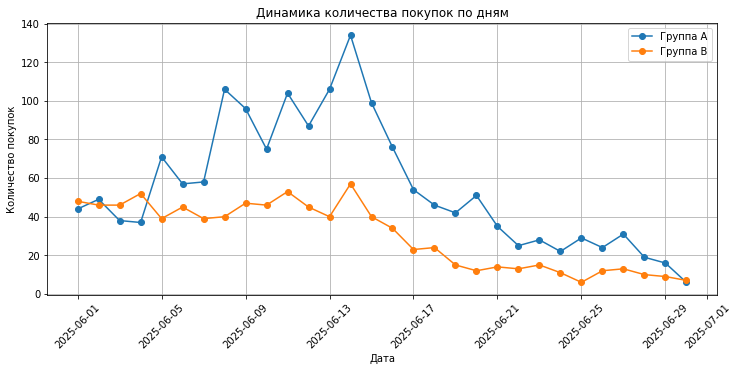

In [22]:
import matplotlib.pyplot as plt

# Сводная таблица для графика
daily_purchases_pivot = daily_purchases.pivot(
    index='date',
    columns='group',
    values='purchases'
).fillna(0)

plt.figure(figsize=(12, 5))
plt.plot(daily_purchases_pivot.index, daily_purchases_pivot['A'], marker='o', label='Группа A')
plt.plot(daily_purchases_pivot.index, daily_purchases_pivot['B'], marker='o', label='Группа B')

plt.title('Динамика количества покупок по дням')
plt.xlabel('Дата')
plt.ylabel('Количество покупок')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

**Посчитаем кумулятивное количество покупок**

In [23]:
# Считаем кумулятивное количество покупок
daily_purchases['cum_purchases'] = daily_purchases.groupby('group')['purchases'].cumsum()

daily_purchases.head()

,date,group,purchases,buyers,revenue,cum_purchases
0,2025-06-01,A,44,44,1629.56,44
1,2025-06-01,B,48,48,1434.52,48
2,2025-06-02,A,49,49,479.51,93
3,2025-06-02,B,46,46,729.54,94
4,2025-06-03,A,38,38,734.62,131


**Построим график кумулятивной динамики покупок**

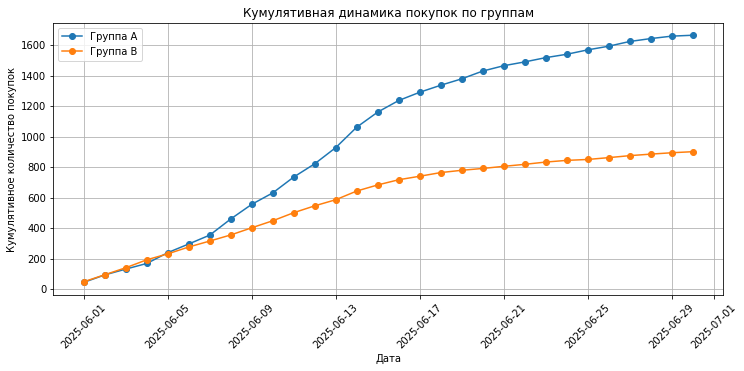

In [24]:
# Сводная таблица для графика
cum_purchases_pivot = daily_purchases.pivot(
    index='date',
    columns='group',
    values='cum_purchases'
).fillna(method='ffill')

plt.figure(figsize=(12, 5))
plt.plot(cum_purchases_pivot.index, cum_purchases_pivot['A'], marker='o', label='Группа A')
plt.plot(cum_purchases_pivot.index, cum_purchases_pivot['B'], marker='o', label='Группа B')

plt.title('Кумулятивная динамика покупок по группам')
plt.xlabel('Дата')
plt.ylabel('Кумулятивное количество покупок')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

**Посчитаем итоговое количество покупок по группам**

In [25]:
# Итоговые показатели по покупкам
purchase_summary = purchases_test.groupby('group').agg(
    purchases=('user_id', 'count'),
    buyers=('user_id', 'nunique'),
    revenue=('revenue', 'sum'),
    avg_check=('revenue', 'mean')
).reset_index()

purchase_summary

,group,purchases,buyers,revenue,avg_check
0,A,1665,472,43073.35,25.869880
1,B,901,270,22475.99,24.945605


### Вывод по исследовательскому анализу A/B-теста

На этапе исследовательского анализа были проанализированы участники A/B-теста `new_payment_funnel_test_summer_2025`.

Для анализа покупок данные из таблицы `purchases` были объединены с таблицей `participants`, чтобы каждой покупке сопоставить группу пользователя — A или B.

Конверсия в покупку рассчитывалась как отношение количества уникальных покупателей к количеству участников соответствующей группы.

По результатам анализа конверсия в группе A оказалась выше, чем в группе B. В группе A конверсия составила около 29.54%, а в группе B — около 18.39%.

Также была построена кумулятивная динамика покупок. График показывает, что количество покупок в группе A накапливается быстрее, чем в группе B. К концу анализируемого периода группа A заметно опережает группу B по общему числу покупок.

Таким образом, на этапе исследовательского анализа новая платёжная воронка не показывает улучшения ключевой метрики. Предварительно можно сделать вывод, что тестовая группа B демонстрирует более слабый результат по сравнению с контрольной группой A.

## Проверка гипотез

**Сформулируем гипотезы**

Так как новая платёжная воронка должна была увеличить конверсию, формулируем гипотезы так:

H0: Конверсия в группе B не выше конверсии в группе A

H1: Конверсия в группе B выше конверсии в группе A

Где:

группа A — контрольная группа;

группа B — тестовая группа с новой платёжной воронкой.

In [26]:
# Проверим гипотезу

from scipy import stats
import numpy as np

# Количество пользователей в группах
users_by_group = participants_test.groupby('group')['user_id'].nunique()

# Количество уникальных покупателей в группах
buyers_by_group = purchases_test.groupby('group')['user_id'].nunique()

# Данные по группам
n_a = users_by_group['A']
n_b = users_by_group['B']

buyers_a = buyers_by_group['A']
buyers_b = buyers_by_group['B']

# Конверсии
conversion_a = buyers_a / n_a
conversion_b = buyers_b / n_b

print('Пользователей в группе A:', n_a)
print('Покупателей в группе A:', buyers_a)
print('Конверсия в группе A:', round(conversion_a * 100, 2), '%')

print('Пользователей в группе B:', n_b)
print('Покупателей в группе B:', buyers_b)
print('Конверсия в группе B:', round(conversion_b * 100, 2), '%')

Пользователей в группе A: 1598
Покупателей в группе A: 472
Конверсия в группе A: 29.54 %
Пользователей в группе B: 1468
Покупателей в группе B: 270
Конверсия в группе B: 18.39 %


**Z-тест для двух долей**

In [27]:
# Объединённая конверсия
p_combined = (buyers_a + buyers_b) / (n_a + n_b)

# Разница конверсий
difference = conversion_b - conversion_a

# Стандартная ошибка
standard_error = np.sqrt(
    p_combined * (1 - p_combined) * (1 / n_a + 1 / n_b)
)

# Z-статистика
z_value = difference / standard_error

# p-value для одностороннего теста:
# H1: конверсия в группе B выше, чем в группе A
p_value = 1 - stats.norm.cdf(z_value)

print('Z-статистика:', z_value)
print('p-value:', p_value)

alpha = 0.05

if p_value < alpha:
    print('Отвергаем нулевую гипотезу: конверсия в группе B статистически значимо выше.')
else:
    print('Не отвергаем нулевую гипотезу: нет оснований считать, что конверсия в группе B выше.')

Z-статистика: -7.197472855046176
p-value: 0.9999999999996934
Не отвергаем нулевую гипотезу: нет оснований считать, что конверсия в группе B выше.


### Вывод по проверке гипотезы

Для проверки гипотезы был применён z-тест для сравнения двух долей, так как основная метрика A/B-теста — конверсия в покупку.

Нулевая гипотеза: конверсия в группе B не выше конверсии в группе A.

Альтернативная гипотеза: конверсия в группе B выше конверсии в группе A.

По результатам анализа конверсия в группе A составила около 29.54%, а в группе B — около 18.39%. Таким образом, тестовая группа B показала более низкую конверсию, чем контрольная группа A.

По результатам статистического теста нет оснований отвергнуть нулевую гипотезу. Мы не можем утверждать, что новая платёжная воронка увеличила конверсию в покупку.

Более того, на текущих данных наблюдается обратная картина: конверсия в группе B ниже, чем в группе A. Поэтому новую платёжную воронку не рекомендуется внедрять без дополнительной проверки причин снижения конверсии.

## Выводы и рекомендации

В рамках проекта были проанализированы результаты A/B-теста `new_payment_funnel_test_summer_2025`, целью которого была проверка гипотезы о том, что новая платёжная воронка увеличит конверсию пользователей в покупку.

На этапе предобработки были изучены четыре датасета: `new_users`, `sessions`, `purchases` и `participants`. В данных были проверены типы данных, пропущенные значения, явные дубликаты и количество уникальных пользователей. Явные дубликаты в датасетах отсутствовали, а столбцы с датами были преобразованы в формат `datetime`, что позволило корректно анализировать динамику пользовательской активности и покупок.

Также была проведена проверка данных по участникам A/B-теста. В датасете `participants` присутствовали данные по нескольким тестам, поэтому для анализа были отобраны только пользователи, участвовавшие в тесте `new_payment_funnel_test_summer_2025`. Это важный момент: если бы данные не были предварительно отфильтрованы, результаты анализа могли бы быть искажены.

Распределение пользователей между группами A и B оказалось близким к равномерному, но не полностью одинаковым: в группе A было 1 598 пользователей, в группе B — 1 468 пользователей. Пользователи не пересекались между группами, то есть один и тот же пользователь не попадал одновременно и в контрольную, и в тестовую группу. Это говорит о том, что разделение пользователей на группы можно считать корректным.

Основной целевой метрикой теста была конверсия в покупку. По результатам анализа конверсия в контрольной группе A составила около 29.54%, а в тестовой группе B — около 18.39%. Таким образом, тестовая группа B показала более низкую конверсию, чем контрольная группа A.

Кумулятивная динамика покупок также показала преимущество группы A. Количество покупок в контрольной группе накапливалось быстрее, чем в тестовой группе. К концу анализируемого периода группа A заметно опережала группу B по общему количеству покупок. Итоговое количество покупок в группе A составило 1 665, а в группе B — 901. Выручка в группе A также была выше: 43 073.35 против 22 475.99 в группе B. При этом средний чек в группах был близким, поэтому основное различие между группами связано не со стоимостью покупок, а именно с количеством покупателей и конверсией.

Для проверки гипотезы был применён z-тест для сравнения двух долей, так как сравнивалась конверсия в покупку между двумя независимыми группами. По результатам статистической проверки не было получено оснований утверждать, что конверсия в группе B статистически значимо выше, чем в группе A. Более того, фактические данные показывают обратную картину: новая платёжная воронка не увеличила конверсию, а тестовая группа показала результат хуже контрольной.

Итоговый вывод: гипотеза о том, что новая платёжная воронка увеличит конверсию пользователей в покупку, не подтвердилась. На текущих данных внедрять новую платёжную воронку в текущем виде не рекомендуется.

Рекомендации заказчику:

1. Не внедрять новую платёжную воронку в текущем виде, так как она не показала улучшения целевой метрики и связана со снижением конверсии.

2. Провести дополнительную диагностику новой платёжной воронки: проверить наличие технических ошибок, проблем с оплатой, скоростью загрузки страниц, некорректной работой интерфейса или ошибок на отдельных устройствах.

3. Изучить поведение пользователей внутри воронки: определить, на каком этапе пользователи чаще всего прекращают путь к покупке и отличается ли этот этап между группами A и B.

4. Дополнительно проанализировать результаты в разрезе устройств и регионов, так как магазин работает преимущественно в Азии, а поведение пользователей может отличаться в зависимости от региона и типа устройства.

5. Перед повторным запуском теста убедиться, что в данных присутствуют только участники одного A/B-теста, а пользователи не пересекаются между экспериментами и группами.

6. Повторить A/B-тест только после доработки новой платёжной воронки и проверки корректности сбора данных.

Таким образом, по результатам анализа контрольная версия платёжной воронки показала лучшие результаты, а новая версия требует доработки перед возможным повторным тестированием.
